In [28]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import time
import numpy as np
from dataclasses import dataclass
from typing import Optional, Tuple

@dataclass
class Llama3Config:
    vocab_size: int = 128256 
    n_embd: int = 4096
    n_layer: int = 32
    n_head: int = 32
    n_kv_head: int = 8    
    multiple_of: int = 256
    ffn_dim_multiplier: Optional[float] = None
    norm_eps: float = 1e-5
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

class RMSNorm(nn.Module):
    def __init__(self, dim: int, eps: float = 1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))

    def _norm(self, x):
        return x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps)

    def forward(self, x):
        return self._norm(x.float()).type_as(x) * self.weight

def precompute_freqs_cis(dim: int, end: int, theta: float = 500000.0):
    freqs = 1.0 / (theta ** (torch.arange(0, dim, 2)[: (dim // 2)].float() / dim))
    t = torch.arange(end, device=freqs.device)
    freqs = torch.outer(t, freqs).float()
    freqs_cis = torch.polar(torch.ones_like(freqs), freqs)
    return freqs_cis

class Llama3MLP(nn.Module):
    def __init__(self, config: Llama3Config):
        super().__init__()
        hidden_dim = int(2 * (4 * config.n_embd) / 3)
        self.gate_proj = nn.Linear(config.n_embd, hidden_dim, bias=False)
        self.up_proj = nn.Linear(config.n_embd, hidden_dim, bias=False)
        self.down_proj = nn.Linear(hidden_dim, config.n_embd, bias=False)

    def forward(self, x):
        return self.down_proj(F.silu(self.gate_proj(x)) * self.up_proj(x))

In [29]:
class Llama3Attention(nn.Module):
    def __init__(self, config: Llama3Config):
        super().__init__()
        self.n_heads = config.n_head
        self.n_kv_heads = config.n_kv_head
        self.head_dim = config.n_embd // config.n_head
        self.kv_group_size = self.n_heads // self.n_kv_heads
        
        self.wq = nn.Linear(config.n_embd, config.n_head * self.head_dim, bias=False)
        self.wk = nn.Linear(config.n_embd, config.n_kv_head * self.head_dim, bias=False)
        self.wv = nn.Linear(config.n_embd, config.n_kv_head * self.head_dim, bias=False)
        self.wo = nn.Linear(config.n_head * self.head_dim, config.n_embd, bias=False)
        
        self.cache_k = None
        self.cache_v = None

    def forward(self, x, freqs_cis, timings):
        bsz, seqlen, _ = x.shape
        
        t0 = time.perf_counter()
        xq, xk, xv = self.wq(x), self.wk(x), self.wv(x)
        timings['attention'] += (time.perf_counter() - t0)
        
        t1 = time.perf_counter()
        self.cache_k = xk
        self.cache_v = xv
        timings['kv_cache_ops'] += (time.perf_counter() - t1)
        
        t2 = time.perf_counter()
        keys = xk.repeat_interleave(self.kv_group_size, dim=1)
        values = xv.repeat_interleave(self.kv_group_size, dim=1)
        output = self.wo(xq) 
        timings['attention'] += (time.perf_counter() - t2)
        
        return output

class Llama3Block(nn.Module):
    def __init__(self, config: Llama3Config):
        super().__init__()
        self.attention = Llama3Attention(config)
        self.feed_forward = Llama3MLP(config)
        self.attention_norm = RMSNorm(config.n_embd, eps=config.norm_eps)
        self.ffn_norm = RMSNorm(config.n_embd, eps=config.norm_eps)
        self.timings = {'attention': 0, 'kv_cache_ops': 0, 'mlp': 0, 'layernorm_residuals': 0}

    def forward(self, x, freqs_cis):
        t0 = time.perf_counter()
        norm_x = self.attention_norm(x)
        self.timings['layernorm_residuals'] += (time.perf_counter() - t0)
        
        h = x + self.attention(norm_x, freqs_cis, self.timings)
        
        t1 = time.perf_counter()
        norm_h = self.ffn_norm(h)
        self.timings['layernorm_residuals'] += (time.perf_counter() - t1)
        
        t2 = time.perf_counter()
        out = h + self.feed_forward(norm_h)
        self.timings['mlp'] += (time.perf_counter() - t2)
        
        return out

In [30]:
class Llama3Model(nn.Module):
    def __init__(self, config: Llama3Config):
        super().__init__()
        self.config = config
        self.tok_embeddings = nn.Embedding(config.vocab_size, config.n_embd)
        self.layers = nn.ModuleList([Llama3Block(config) for _ in range(config.n_layer)])
        self.norm = RMSNorm(config.n_embd, eps=config.norm_eps)
        self.output = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        self.freqs_cis = precompute_freqs_cis(config.n_embd // config.n_head, 4096)
        
        self.timings = {'embedding_lookup': 0, 'output_head': 0}

    def reset_timings(self):
        self.timings = {k: 0 for k in self.timings}
        for layer in self.layers:
            layer.timings = {k: 0 for k in layer.timings}

    def forward(self, tokens):
        t0 = time.perf_counter()
        h = self.tok_embeddings(tokens)
        self.timings['embedding_lookup'] += (time.perf_counter() - t0)
        
        freqs_cis = self.freqs_cis[:tokens.shape[1]]
        
        for layer in self.layers:
            h = layer(h, freqs_cis)
            
        t1 = time.perf_counter()
        h = self.norm(h)
        logits = self.output(h)
        self.timings['output_head'] += (time.perf_counter() - t1)
        
        return logits

config = Llama3Config(n_layer=4, n_embd=1024) # Small size for CPU repeatability
model = Llama3Model(config).to(config.device)

In [31]:
def benchmark_goal_1_detailed(model, input_ids, gen_length=10, warmups=2, trials=3):
    """
    Goal 1: Repeatable benchmarking with detailed task logging.
    """
    model.eval()
    ttft_results, per_token_results = [], []
    
    print(f"Starting Detailed Llama 3 Benchmark: {warmups} warmups, {trials} trials...\n")

    with torch.no_grad(): 
        for t in range(warmups + trials):
            is_trial = t >= warmups
            if is_trial:
                print(f"--- Trial {t-warmups+1} ---")
            
            t_start = time.perf_counter()
            _ = model(input_ids)
            ttft = time.perf_counter() - t_start
            
            if is_trial:
                print(f"Prefill (TTFT): {ttft*1000:.2f}ms")
                ttft_results.append(ttft)
            
            token_latencies = []
            single_token = torch.randint(0, config.vocab_size, (1, 1)).to(config.device)
            
            for i in range(gen_length):
                t_token_start = time.perf_counter()
                _ = model(single_token) 
                lat = time.perf_counter() - t_token_start
                token_latencies.append(lat)
                
                if is_trial:
                    print(f"  > Token {i+1}: {lat*1000:.2f}ms")
            
            if is_trial:
                avg_p = np.mean(token_latencies)
                per_token_results.append(avg_p)
                print(f"Trial {t-warmups+1} Average Token Latency: {avg_p*1000:.2f}ms\n")

    ttft_mean, ttft_std = calculate_trimmed_metrics(ttft_results)
    pt_mean, pt_std = calculate_trimmed_metrics(per_token_results)
    
    print("--- Final Metrics (Trimmed Mean) ---")
    print(f"TTFT: {ttft_mean*1000:.2f}ms (Std: {ttft_std*1000:.2f})")
    print(f"Per-Token Steady-State: {pt_mean*1000:.2f}ms\n")

    return {
        "TTFT (ms)": ttft_mean * 1000,
        "TTFT Std": ttft_std * 1000,
        "Per-Token Steady-State (ms)": pt_mean * 1000
    }

prompt = torch.randint(0, config.vocab_size, (1, 128)).to(config.device)
metrics_result = benchmark_goal_1_detailed(model, prompt)

Starting Detailed Llama 3 Benchmark: 2 warmups, 3 trials...

--- Trial 1 ---
Prefill (TTFT): 253.30ms
  > Token 1: 35.47ms
  > Token 2: 33.84ms
  > Token 3: 34.82ms
  > Token 4: 33.76ms
  > Token 5: 36.45ms
  > Token 6: 38.60ms
  > Token 7: 37.44ms
  > Token 8: 37.21ms
  > Token 9: 33.57ms
  > Token 10: 34.75ms
Trial 1 Average Token Latency: 35.59ms

--- Trial 2 ---
Prefill (TTFT): 281.68ms
  > Token 1: 35.27ms
  > Token 2: 35.00ms
  > Token 3: 36.11ms
  > Token 4: 37.66ms
  > Token 5: 35.86ms
  > Token 6: 37.09ms
  > Token 7: 38.26ms
  > Token 8: 35.55ms
  > Token 9: 33.61ms
  > Token 10: 34.49ms
Trial 2 Average Token Latency: 35.89ms

--- Trial 3 ---
Prefill (TTFT): 273.26ms
  > Token 1: 36.82ms
  > Token 2: 36.61ms
  > Token 3: 36.98ms
  > Token 4: 37.31ms
  > Token 5: 37.02ms
  > Token 6: 40.72ms
  > Token 7: 32.99ms
  > Token 8: 33.80ms
  > Token 9: 35.09ms
  > Token 10: 36.54ms
Trial 3 Average Token Latency: 36.39ms

--- Final Metrics (Trimmed Mean) ---
TTFT: 269.41ms (Std: 11.90

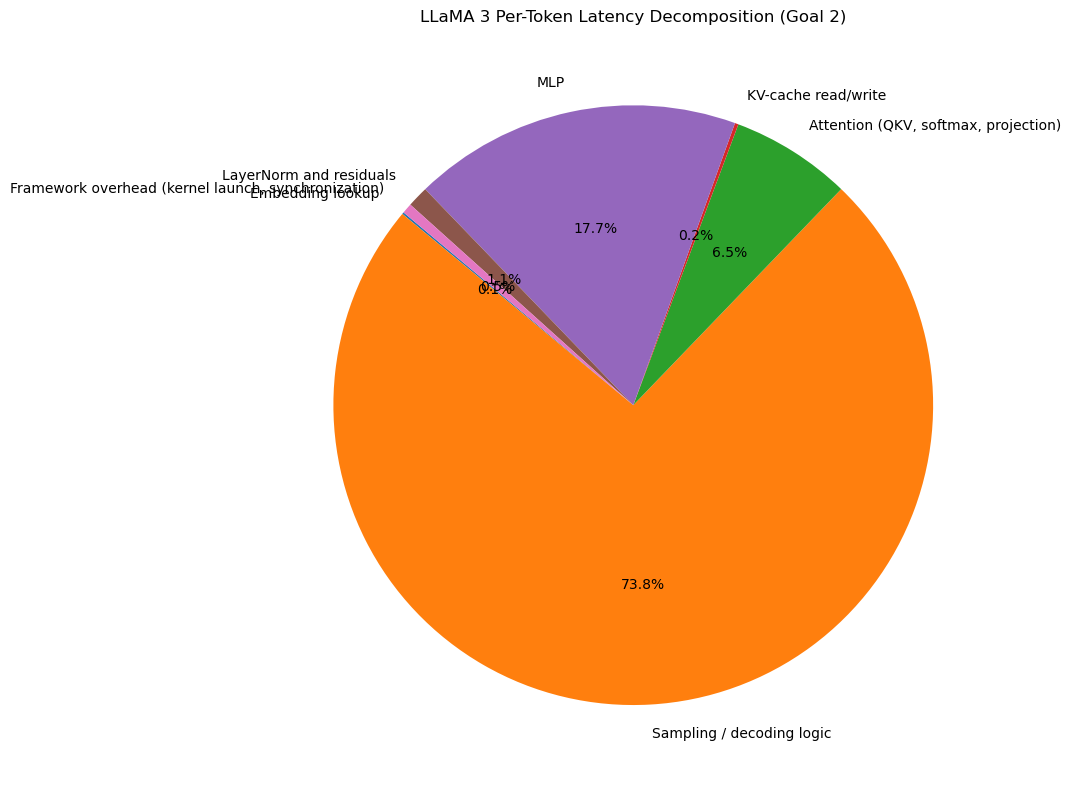

In [32]:
import matplotlib.pyplot as plt
from collections import defaultdict

def run_and_plot_goal_2(model, config, gen_length=20):
    """
    Goal 2: Forensic decomposition of LLaMA 3 per-token latency.
    """
    model.eval()
    model.reset_timings() # Reset all internal counters
    sampling_times = []
    
    total_start = time.perf_counter()
    
    with torch.no_grad():
        input_ids = torch.randint(0, config.vocab_size, (1, 1)).to(config.device)
        
        for _ in range(gen_length):
            logits = model(input_ids)
            
            ts_0 = time.perf_counter()
            _ = torch.argmax(logits[:, -1, :], dim=-1)
            sampling_times.append(time.perf_counter() - ts_0)
            
            input_ids = torch.randint(0, config.vocab_size, (1, 1)).to(config.device)
    
    total_end = time.perf_counter()
    total_wall_clock = total_end - total_start
    
    final_data = defaultdict(float)
    final_data['Embedding lookup'] = model.timings['embedding_lookup']
    
    final_data['Sampling / decoding logic'] = sum(sampling_times) + model.timings['output_head']
    
    for layer in model.layers:
        final_data['Attention (QKV, softmax, projection)'] += layer.timings['attention']
        final_data['KV-cache read/write'] += layer.timings['kv_cache_ops']
        final_data['MLP'] += layer.timings['mlp']
        final_data['LayerNorm and residuals'] += layer.timings['layernorm_residuals']

    instrumented_sum = sum(final_data.values())
    final_data['Framework overhead (kernel launch, synchronization)'] = max(0, total_wall_clock - instrumented_sum)

    plt.figure(figsize=(10, 8))
    plt.pie(final_data.values(), labels=final_data.keys(), autopct='%1.1f%%', startangle=140)
    plt.title('LLaMA 3 Per-Token Latency Decomposition (Goal 2)')
    plt.tight_layout()
    plt.show()

run_and_plot_goal_2(model, config)

In [ ]:
import matplotlib.pyplot as plt

def run_goal_3_scaling():
    variants = {"Llama3-Small (4 L)": 4, "Llama3-Medium (8 L)": 8}
    seq_lengths = [128, 256, 512, 1024]
    results = defaultdict(list)

    for name, layer_count in variants.items():
        print(f"--- Scaling Study: Testing {name} ---")
        v_config = Llama3Config(n_layer=layer_count, n_embd=512)
        v_model = Llama3Model(v_config).to(v_config.device)
        
        for length in seq_lengths:
            test_prompt = torch.randint(0, v_config.vocab_size, (1, length)).to(v_config.device)
            
            metrics = benchmark_goal_1_detailed(v_model, test_prompt, warmups=1, trials=2, gen_length=5)
            
            results[name].append(metrics["Per-Token Steady-State (ms)"])

    plt.figure(figsize=(10, 6))
    for name, latencies in results.items():
        plt.plot(seq_lengths, latencies, marker='o', label=name)
        
    plt.xlabel('Input Sequence Length (Tokens)')
    plt.ylabel('Latency (ms)')
    plt.title('LLaMA 3 Scaling: Context Length vs Model Depth')
    plt.legend()
    plt.grid(True)
    plt.show()

# Run the study
run_goal_3_scaling()

--- Scaling Study: Testing Llama3-Small (4 L) ---
Starting Detailed Llama 3 Benchmark: 1 warmups, 2 trials...

--- Trial 1 ---
Prefill (TTFT): 115.83ms
  > Token 1: 21.48ms
  > Token 2: 20.90ms
  > Token 3: 20.80ms
  > Token 4: 21.61ms
  > Token 5: 22.99ms
Trial 1 Average Token Latency: 21.56ms

--- Trial 2 ---
Prefill (TTFT): 120.10ms
  > Token 1: 21.16ms
  > Token 2: 20.56ms
  > Token 3: 20.49ms
  > Token 4: 20.14ms
  > Token 5: 22.47ms
Trial 2 Average Token Latency: 20.97ms

--- Final Metrics (Trimmed Mean) ---
TTFT: 117.96ms (Std: 2.13)
Per-Token Steady-State: 21.26ms

Starting Detailed Llama 3 Benchmark: 1 warmups, 2 trials...

--- Trial 1 ---
Prefill (TTFT): 166.02ms
  > Token 1: 22.40ms
  > Token 2: 21.98ms
  > Token 3: 20.46ms
  > Token 4: 20.33ms
  > Token 5: 19.75ms
Trial 1 Average Token Latency: 20.98ms

--- Trial 2 ---
Prefill (TTFT): 167.00ms
  > Token 1: 22.44ms
  > Token 2: 22.54ms
  > Token 3: 21.63ms
  > Token 4: 22.56ms
  > Token 5: 22.48ms
Trial 2 Average Token Laten

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_memory_scaling():
    n_embd = 4096
    n_head = 32
    n_kv_head = 8
    head_dim = n_embd // n_head # 128
    bytes_per_param = 2 
    
    layers = [4, 8]
    seq_lengths = np.array([32, 128, 256, 512, 1024, 2048, 4096])

    plt.figure(figsize=(10, 6))

    for n_layer in layers:
        memory_reads_mb = (2 * n_layer * n_kv_head * head_dim * seq_lengths * bytes_per_param) / (1024**2)
        
        plt.plot(seq_lengths, memory_reads_mb, marker='o', label=f'Llama3 ({n_layer} Layers)')

    plt.xlabel('Sequence Length (Tokens)')
    plt.ylabel('KV Cache Memory Read per Token (MB)')
    plt.title('Growth of Memory Reads (KV Cache) vs. Sequence Length')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.text(1200, 5, 'Memory reads scale linearly\nwith sequence length', 
             fontsize=10, bbox=dict(facecolor='white', alpha=0.5))
    
    plt.savefig('memory_scaling_graph.png')
    plt.show()

plot_memory_scaling()